# ============================================
# Ridge (L2) sin escalar, OHE solo en Ticker/nombre_holding
# Fix: dummies con dtype numérico (np.uint8)
# ============================================

In [2]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ---- Ruta ----
PATH = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

# ---- Carga ----
df = pd.read_csv(PATH)
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# ---- Limpieza útil ----
if "insider_rating" in df.columns:
    df["insider_rating"] = pd.to_numeric(
        df["insider_rating"].astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

# ---- Encoding cíclico: quarter (1..4) ----
if "quarter" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter'.")
q = pd.to_numeric(df["quarter"], errors="coerce")
df["quarter_sin"] = np.sin(2*np.pi*q/4)
df["quarter_cos"] = np.cos(2*np.pi*q/4)

# ---- Encoding cíclico: quarter - year ('YYYY-MM-DD' o 'Qn YYYY') ----
if "quarter - year" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter - year'.")

qy_raw = df["quarter - year"].astype(str)
qy_dt = pd.to_datetime(qy_raw, errors="coerce")
mask_nan = qy_dt.isna()
if mask_nan.any():
    def q_to_date(txt):
        m = re.match(r"Q([1-4])\s+(\d{4})", str(txt))
        if not m:
            return pd.NaT
        qn = int(m.group(1)); yy = int(m.group(2))
        month_end = {1:3, 2:6, 3:9, 4:12}[qn]
        return pd.Timestamp(year=yy, month=month_end, day=1) + pd.offsets.MonthEnd(0)
    qy_dt.loc[mask_nan] = qy_raw[mask_nan].map(q_to_date)

qy_quarter = qy_dt.dt.quarter.astype("float64")
df["quarter_year_sin"] = np.sin(2*np.pi*qy_quarter/4)
df["quarter_year_cos"] = np.cos(2*np.pi*qy_quarter/4)

# ---- Eliminar par cíclico duplicado si coincide ----
try:
    same_sin = np.allclose(df["quarter_sin"].to_numpy(), df["quarter_year_sin"].to_numpy(), equal_nan=True)
    same_cos = np.allclose(df["quarter_cos"].to_numpy(), df["quarter_year_cos"].to_numpy(), equal_nan=True)
    if same_sin and same_cos:
        df.drop(columns=["quarter_year_sin", "quarter_year_cos"], inplace=True)
        print("ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.")
except KeyError:
    pass

# ---- Eliminar columnas de fecha crudas ----
for col in ["quarter - year", "Date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# ---- Target y categóricas ----
target_col = "activity_act"
if target_col not in df.columns:
    raise ValueError("No se encontró la columna target 'activity_act'.")
df = df.dropna(subset=[target_col]).reset_index(drop=True)

cat_cols = [c for c in ["Ticker", "nombre_holding"] if c in df.columns]

# ---- OHE SOLO en categóricas indicadas, forzando dtype numérico ----
df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=np.uint8)

# ---- X / y ----
y = df_ohe[target_col]
X = df_ohe.drop(columns=[target_col])

# ---- Convertir cualquier boolean remanente a uint8 (defensa extra) ----
bool_cols = X.select_dtypes(include=["boolean"]).columns.tolist()
for c in bool_cols:
    X[c] = X[c].astype(np.uint8)

# ---- Chequeo: todo X debe ser numérico ----
non_numeric_left = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_left:
    raise TypeError(f"Quedaron columnas no numéricas en X (revisa tu data): {non_numeric_left}")

# ---- Imputación mediana (solo numéricas) ----
X = X.fillna(X.median(numeric_only=True))

# ---- Train/Test ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- Ridge (L2) sin escalar ----
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# ---- Métrica y coeficientes ----
y_pred = model.predict(X_test)
print(f"📈 R² test (sin escalar): {r2_score(y_test, y_pred):.4f}")

coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
print("\n🏆 Top 15 features (|coef| más alto) — unidades reales:")
print(coefs.head(20))


✅ Dataset cargado: 10,876 filas × 14 columnas
ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.
📈 R² test (sin escalar): 0.3139

🏆 Top 15 features (|coef| más alto) — unidades reales:
Ticker_NVR      1.537889
Ticker_GRBK    -0.889112
Ticker_BHF     -0.856347
Ticker_CNH     -0.842418
Ticker_SHC     -0.795735
Ticker_CMG     -0.768069
Ticker_HLT     -0.763226
Ticker_LBTYK   -0.740257
Ticker_FICO     0.738702
Ticker_GPRO    -0.724716
Ticker_VSAT    -0.721100
Ticker_WFRD    -0.694633
Ticker_STZ      0.622350
Ticker_GPK     -0.617261
Ticker_LNC      0.612278
Ticker_ORLY    -0.579552
Ticker_KMX     -0.575967
Ticker_CB       0.567568
Ticker_UAN      0.557346
Ticker_TXN      0.548053
dtype: float64


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.422e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [3]:
# ---- Vista previa del dataset final después de los encodajes ----
print("\n📊 Vista general del dataset post-encoding:")
print(f"Shape final: {df_ohe.shape[0]:,} filas × {df_ohe.shape[1]} columnas\n")

# Muestra primeras filas
display(df_ohe.head(5))

# Info general (tipos y nulos)
print("\n📋 Información general:")
print(df_ohe.info())

# Estadísticas básicas de las variables numéricas
print("\n📈 Estadísticas descriptivas:")
display(df_ohe.describe().T.head(10))



📊 Vista general del dataset post-encoding:
Shape final: 10,876 filas × 244 columnas



,diferencia_cierre_vs_apertura,activity_act,activity_porc,Adj Close,Operacion_insider,insider_rating,ebitda,netIncome,eps_surprise,year,...,nombre_holding_FS,nombre_holding_GLRE,nombre_holding_HC,nombre_holding_LMM,nombre_holding_PI,nombre_holding_SAM,nombre_holding_ic,nombre_holding_oc,nombre_holding_psc,nombre_holding_tp
0,-3.278008,0,0.0370,121.419495,0,1.0,1.823700e+10,1.267300e+10,0.03,2020,...,0,0,0,0,0,0,0,0,0,0
1,-2.953438,0,0.0605,109.936562,0,1.0,3.688300e+10,2.875500e+10,0.26,2020,...,0,0,0,0,0,0,0,0,0,0
2,-2.953438,1,1.0000,109.936562,0,1.0,3.688300e+10,2.875500e+10,0.26,2020,...,0,0,1,0,0,0,0,0,0,0
3,-1.501190,0,0.0605,113.778809,0,1.0,3.688300e+10,2.875500e+10,0.26,2020,...,0,0,0,0,0,0,0,0,0,0
4,-1.501190,1,1.0000,113.778809,0,1.0,3.688300e+10,2.875500e+10,0.26,2020,...,0,0,1,0,0,0,0,0,0,0



📋 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10876 entries, 0 to 10875
Columns: 244 entries, diferencia_cierre_vs_apertura to nombre_holding_tp
dtypes: float64(9), int64(4), uint8(231)
memory usage: 3.5 MB
None

📈 Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
diferencia_cierre_vs_apertura,10876.0,-2.247098e+00,7.289926e+00,-1.383500e+02,-4.038513e+00,-1.122330e+00,3.755035e-01,8.639990e+01
activity_act,10876.0,4.047444e-01,4.908651e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
activity_porc,10876.0,5.283675e-01,3.557853e+00,0.000000e+00,3.160000e-02,1.238000e-01,4.406000e-01,1.015553e+02
Adj Close,10876.0,2.124022e+02,2.904005e+02,1.420000e+00,7.609805e+01,1.406286e+02,2.687349e+02,5.898820e+03
Operacion_insider,10876.0,6.905112e-02,2.535527e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
insider_rating,10876.0,8.632769e-01,3.435705e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
ebitda,10876.0,1.015725e+10,1.185260e+10,-7.406000e+09,4.440000e+08,3.114000e+09,2.143800e+10,4.631000e+10
netIncome,10876.0,6.755785e+09,8.495212e+09,-1.663900e+10,1.993000e+08,1.693000e+09,1.401700e+10,3.633000e+10
eps_surprise,10876.0,1.933245e-01,8.346986e-01,-9.480000e+00,5.200000e-03,9.000000e-02,2.700000e-01,3.187000e+01
year,10876.0,2.023106e+03,1.402943e+00,2.020000e+03,2.022000e+03,2.023000e+03,2.024000e+03,2.025000e+03


# ============================================
# Ridge (L2) con estandarización (StandardScaler)
# - Encoding cíclico: quarter, quarter - year
# - Elimina duplicados cíclicos si coinciden
# - Drop columnas "quarter - year" y "Date"
# - One-Hot Encoding SOLO en ["Ticker", "nombre_holding"]
# - Estandariza todas las variables numéricas (mantiene la interpretación estadística)
# - Entrena Ridge y muestra R² + Top 15 coeficientes
# ============================================

In [12]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ---- Ruta ----
PATH = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

# ---- Carga ----
df = pd.read_csv(PATH)
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# ---- Limpieza útil ----
if "insider_rating" in df.columns:
    df["insider_rating"] = pd.to_numeric(
        df["insider_rating"].astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

# ---- Encoding cíclico: quarter (1..4) ----
if "quarter" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter'.")
q = pd.to_numeric(df["quarter"], errors="coerce")
df["quarter_sin"] = np.sin(2*np.pi*q/4)
df["quarter_cos"] = np.cos(2*np.pi*q/4)

# ---- Encoding cíclico: quarter - year ----
if "quarter - year" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter - year'.")

qy_raw = df["quarter - year"].astype(str)
qy_dt = pd.to_datetime(qy_raw, errors="coerce")
mask_nan = qy_dt.isna()
if mask_nan.any():
    def q_to_date(txt):
        m = re.match(r"Q([1-4])\s+(\d{4})", str(txt))
        if not m:
            return pd.NaT
        qn = int(m.group(1)); yy = int(m.group(2))
        month_end = {1:3, 2:6, 3:9, 4:12}[qn]
        return pd.Timestamp(year=yy, month=month_end, day=1) + pd.offsets.MonthEnd(0)
    qy_dt.loc[mask_nan] = qy_raw[mask_nan].map(q_to_date)

qy_quarter = qy_dt.dt.quarter.astype("float64")
df["quarter_year_sin"] = np.sin(2*np.pi*qy_quarter/4)
df["quarter_year_cos"] = np.cos(2*np.pi*qy_quarter/4)

# ---- Eliminar par cíclico duplicado ----
try:
    same_sin = np.allclose(df["quarter_sin"].to_numpy(), df["quarter_year_sin"].to_numpy(), equal_nan=True)
    same_cos = np.allclose(df["quarter_cos"].to_numpy(), df["quarter_year_cos"].to_numpy(), equal_nan=True)
    if same_sin and same_cos:
        df.drop(columns=["quarter_year_sin", "quarter_year_cos"], inplace=True)
        print("ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.")
except KeyError:
    pass

# ---- Eliminar columnas de fecha crudas ----
for col in ["quarter - year", "Date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# ---- Target y categóricas ----
target_col = "activity_act"
if target_col not in df.columns:
    raise ValueError("No se encontró la columna target 'activity_act'.")
df = df.dropna(subset=[target_col]).reset_index(drop=True)

cat_cols = [c for c in ["Ticker", "nombre_holding"] if c in df.columns]

# ---- OHE (solo las categóricas definidas, dtype numérico) ----
df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=np.uint8)

# ---- X / y ----
y = df_ohe[target_col]
X = df_ohe.drop(columns=[target_col])

# ---- Conversión booleana -> numérica (defensa extra) ----
bool_cols = X.select_dtypes(include=["boolean"]).columns.tolist()
for c in bool_cols:
    X[c] = X[c].astype(np.uint8)

# ---- Imputación de medianas ----
X = X.fillna(X.median(numeric_only=True))

# ---- Estandarización ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ---- Train/Test ----
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ---- Ridge con estandarización ----
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# ---- Resultados ----
y_pred = model.predict(X_test)
print(f"📈 R² test (con estandarización): {r2_score(y_test, y_pred):.4f}")

coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
print("\n🏆 Top 15 features (|coef| más alto) — valores estandarizados:")
print(coefs.head(15))

# ---- Vista rápida del dataset post-encoding ----
print("\n📊 Vista general del dataset estandarizado:")
print(f"Shape final: {X_scaled.shape[0]:,} filas × {X_scaled.shape[1]} columnas\n")
display(X_scaled.head(5))


✅ Dataset cargado: 10,876 filas × 14 columnas
ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.
📈 R² test (con estandarización): 0.3139

🏆 Top 15 features (|coef| más alto) — valores estandarizados:
Adj Close             -0.150254
Ticker_NVR             0.127273
Ticker_GOOG           -0.123604
ebitda                -0.122519
Ticker_ORLY           -0.097418
Ticker_CMG            -0.092979
nombre_holding_GLRE    0.087352
nombre_holding_tp      0.076375
Ticker_QSR            -0.067267
nombre_holding_psc     0.066644
nombre_holding_LMM    -0.066412
quarter               -0.065564
Ticker_KMX            -0.062770
Ticker_BHF            -0.061232
nombre_holding_HC      0.060158
dtype: float64

📊 Vista general del dataset estandarizado:
Shape final: 10,876 filas × 243 columnas



,diferencia_cierre_vs_apertura,activity_porc,Adj Close,Operacion_insider,insider_rating,ebitda,netIncome,eps_surprise,year,quarter,...,nombre_holding_FS,nombre_holding_GLRE,nombre_holding_HC,nombre_holding_LMM,nombre_holding_PI,nombre_holding_SAM,nombre_holding_ic,nombre_holding_oc,nombre_holding_psc,nombre_holding_tp
0,-0.141422,-0.138114,-0.313315,-0.272347,0.397966,0.681717,0.696567,-0.195678,-2.214357,0.654901,...,-0.523577,-0.198927,-0.115835,-0.242488,-0.086082,-0.126388,-0.09778,-0.078137,-0.198677,-0.367001
1,-0.096897,-0.131509,-0.352859,-0.272347,0.397966,2.254947,2.589721,0.079883,-2.214357,1.552192,...,-0.523577,-0.198927,-0.115835,-0.242488,-0.086082,-0.126388,-0.09778,-0.078137,-0.198677,-0.367001
2,-0.096897,0.132567,-0.352859,-0.272347,0.397966,2.254947,2.589721,0.079883,-2.214357,1.552192,...,-0.523577,-0.198927,8.632947,-0.242488,-0.086082,-0.126388,-0.09778,-0.078137,-0.198677,-0.367001
3,0.102325,-0.131509,-0.339627,-0.272347,0.397966,2.254947,2.589721,0.079883,-2.214357,1.552192,...,-0.523577,-0.198927,-0.115835,-0.242488,-0.086082,-0.126388,-0.09778,-0.078137,-0.198677,-0.367001
4,0.102325,0.132567,-0.339627,-0.272347,0.397966,2.254947,2.589721,0.079883,-2.214357,1.552192,...,-0.523577,-0.198927,8.632947,-0.242488,-0.086082,-0.126388,-0.09778,-0.078137,-0.198677,-0.367001


ℹ️ Usando df_ohe ya encodado en memoria.

🕒 Fold 1 — Train: 1816, Test: 1812


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:26:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🕒 Fold 2 — Train: 3628, Test: 1812


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:28:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🕒 Fold 3 — Train: 5440, Test: 1812


...

/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:33:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🕒 Fold 5 — Train: 9064, Test: 1812


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [19:35:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Resultados promedio ± std por modelo (prioriza Precision):


Precision              Recall                  F1             ROC-AUC  \
            mean       std      mean       std      mean       std      mean   
Modelo                                                                         
LogReg  0.573849  0.168315  0.095939  0.054048  0.156910  0.067969  0.590320   
RF      0.588641  0.127963  0.590398  0.096372  0.587311  0.106576  0.701464   
XGB     0.538004  0.146141  0.586061  0.090095  0.556047  0.114836  0.662697   

                    PR-AUC            
             std      mean       std  
Modelo                                
LogReg  0.061359  0.476218  0.132930  
RF      0.123614  0.609403  0.122345  
XGB     0.114741  0.605686  0.127262

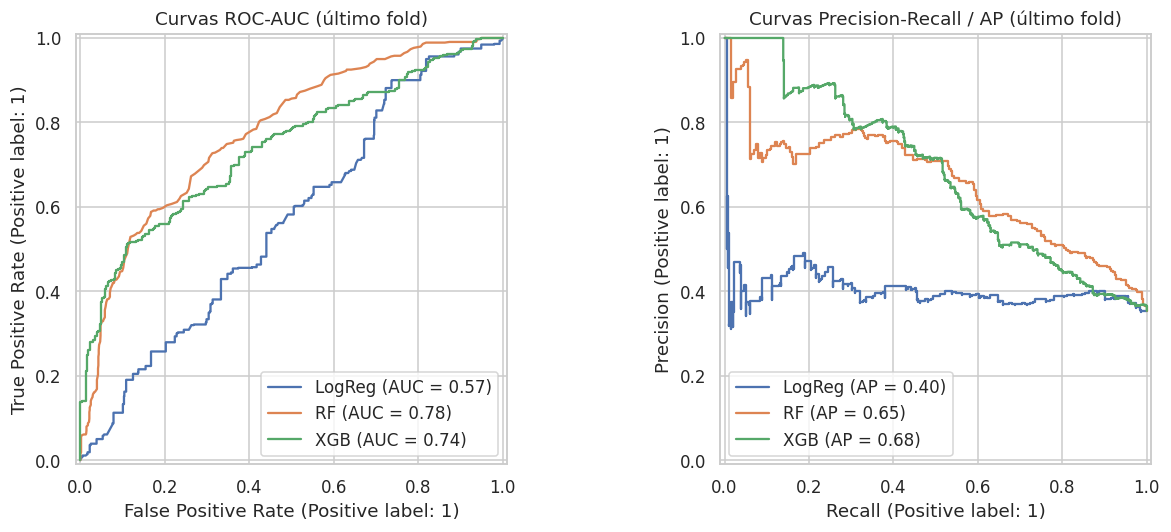

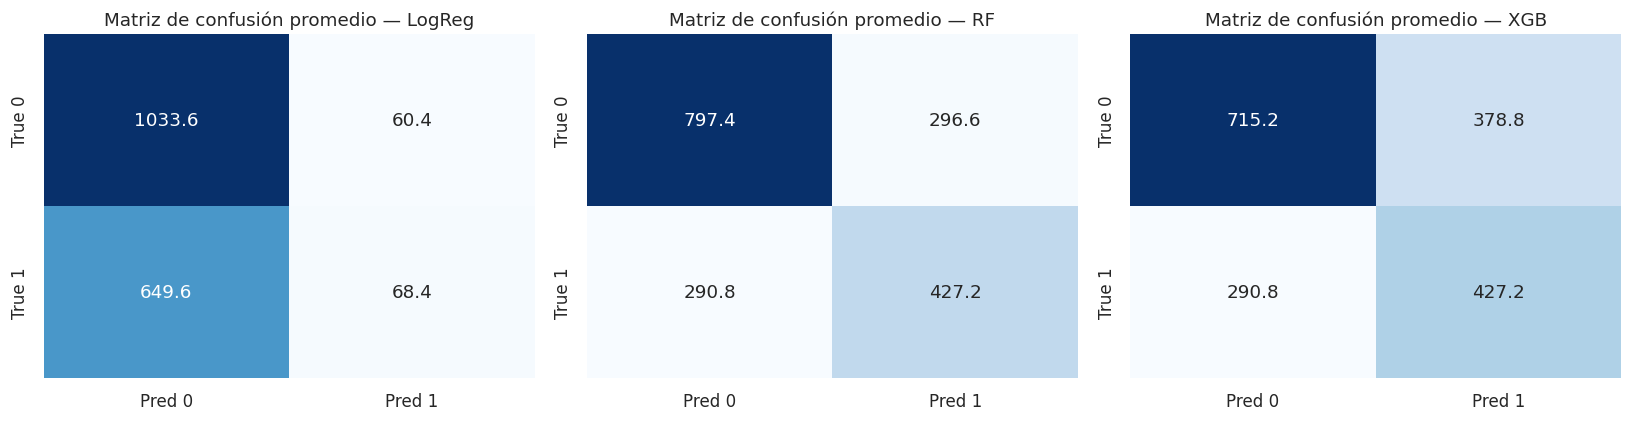

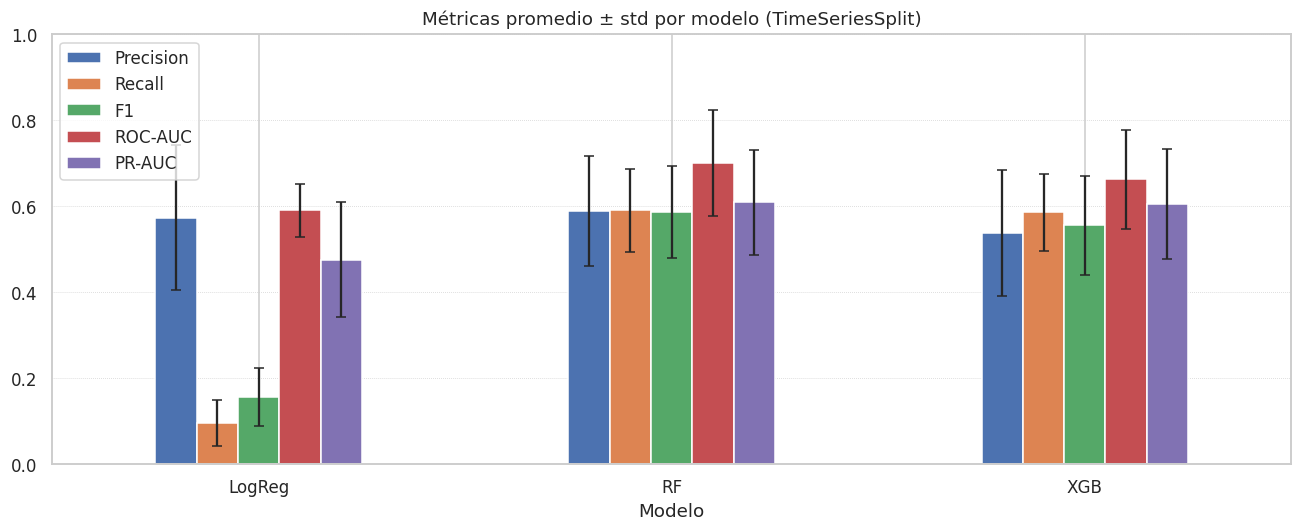

🏆 Ranking por Precision (↑):


,Precision,F1,ROC-AUC,PR-AUC
Modelo,,,,
RF,0.588641,0.587311,0.701464,0.609403
LogReg,0.573849,0.156910,0.590320,0.476218
XGB,0.538004,0.556047,0.662697,0.605686


In [5]:
# ============================================
# Clasificación con validación temporal (TimeSeriesSplit)
# Dataset NO estandarizado, ya encodado (o se encoda si no existe df_ohe)
# Modelos: LogisticRegression, RandomForest, XGBoost
# Métricas: Precision (prioridad), Recall, F1, ROC-AUC, PR-AUC(AP)
# Visualizaciones: ROC, PR, Matriz de confusión promedio, Barras métricas
# ============================================
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# xgboost opcional (si no lo tienes instalado, comenta estas dos líneas y el dict de modelos)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# -------------------------------------------------
# 0) Dataset encodado (usa df_ohe si ya existe; si no, carga y encoda)
# -------------------------------------------------
def build_encoded_df_if_needed():
    global df_ohe  # si ya existe, se usa
    try:
        df_encoded = df_ohe.copy()
        print("ℹ️ Usando df_ohe ya encodado en memoria.")
        return df_encoded
    except NameError:
        print("ℹ️ df_ohe no existe en memoria; se construye desde el CSV…")

    PATH = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"
    df = pd.read_csv(PATH)

    # Limpieza útil
    if "insider_rating" in df.columns:
        df["insider_rating"] = pd.to_numeric(
            df["insider_rating"].astype(str).str.replace(",", ".", regex=False).str.strip(),
            errors="coerce"
        )

    # Encoding cíclico: quarter
    if "quarter" not in df.columns:
        raise ValueError("Falta 'quarter'.")
    q = pd.to_numeric(df["quarter"], errors="coerce")
    df["quarter_sin"] = np.sin(2*np.pi*q/4)
    df["quarter_cos"] = np.cos(2*np.pi*q/4)

    # Encoding cíclico: quarter - year ('YYYY-MM-DD' o 'Qn YYYY')
    if "quarter - year" not in df.columns:
        raise ValueError("Falta 'quarter - year'.")
    qy_raw = df["quarter - year"].astype(str)
    qy_dt = pd.to_datetime(qy_raw, errors="coerce")
    mask_nan = qy_dt.isna()
    if mask_nan.any():
        def q_to_date(txt):
            m = re.match(r"Q([1-4])\s+(\d{4})", str(txt))
            if not m:
                return pd.NaT
            qn = int(m.group(1)); yy = int(m.group(2))
            month_end = {1:3, 2:6, 3:9, 4:12}[qn]
            return pd.Timestamp(year=yy, month=month_end, day=1) + pd.offsets.MonthEnd(0)
        qy_dt.loc[mask_nan] = qy_raw[mask_nan].map(q_to_date)

    qy_quarter = qy_dt.dt.quarter.astype("float64")
    df["quarter_year_sin"] = np.sin(2*np.pi*qy_quarter/4)
    df["quarter_year_cos"] = np.cos(2*np.pi*qy_quarter/4)

    # Eliminar duplicado cíclico si coincide
    try:
        same_sin = np.allclose(df["quarter_sin"].to_numpy(), df["quarter_year_sin"].to_numpy(), equal_nan=True)
        same_cos = np.allclose(df["quarter_cos"].to_numpy(), df["quarter_year_cos"].to_numpy(), equal_nan=True)
        if same_sin and same_cos:
            df.drop(columns=["quarter_year_sin", "quarter_year_cos"], inplace=True)
            print("ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.")
    except KeyError:
        pass

    # Eliminar columnas de fecha crudas
    for col in ["quarter - year", "Date"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Target y categóricas
    target_col = "activity_act"
    if target_col not in df.columns:
        raise ValueError("Falta el target 'activity_act'.")
    df = df.dropna(subset=[target_col]).reset_index(drop=True)

    cat_cols = [c for c in ["Ticker", "nombre_holding"] if c in df.columns]
    df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=np.uint8)

    # Asegurar numeric y sin NaN
    X = df_encoded.drop(columns=[target_col])
    df_encoded[X.columns] = X.fillna(X.median(numeric_only=True))

    return df_encoded

df_encoded = build_encoded_df_if_needed()
target_col = "activity_act"
y = df_encoded[target_col].astype(int)
X = df_encoded.drop(columns=[target_col])

# -------------------------------------------------
# 1) Validación temporal (TimeSeriesSplit)
# -------------------------------------------------
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# -------------------------------------------------
# 2) Modelos (sin estandarizar)
#    - Precision es prioridad, pero medimos también Recall, F1, ROC-AUC y PR-AUC (AP)
# -------------------------------------------------
models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1),
    "XGB": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        use_label_encoder=False, eval_metric="logloss", n_jobs=-1
    )
}

# Para almacenar resultados por fold y modelo
rows = []
# Para curvas del último fold
last_fold_data = {}

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X, y), start=1):
    X_train, X_test = X.iloc[tr_idx], X.iloc[te_idx]
    y_train, y_test = y.iloc[tr_idx], y.iloc[te_idx]
    print(f"\n🕒 Fold {fold} — Train: {len(tr_idx)}, Test: {len(te_idx)}")

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        # predict_proba para ROC/PR
        y_proba = model.predict_proba(X_test)[:, 1]

        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        roc  = roc_auc_score(y_test, y_proba)
        ap   = average_precision_score(y_test, y_proba)

        # Matriz de confusión (TN, FP, FN, TP)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()

        rows.append({
            "Fold": fold, "Modelo": name,
            "Precision": prec, "Recall": rec, "F1": f1,
            "ROC-AUC": roc, "PR-AUC": ap,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp
        })

        # Guardar para gráficas del último fold
        if fold == n_splits:
            last_fold_data[name] = (model, X_test, y_test)

results_df = pd.DataFrame(rows)

# -------------------------------------------------
# 3) Resumen de métricas y matriz de confusión promedio
# -------------------------------------------------
summary = results_df.groupby("Modelo")[["Precision","Recall","F1","ROC-AUC","PR-AUC"]].agg(["mean","std"])
print("\n📊 Resultados promedio ± std por modelo (prioriza Precision):")
display(summary)

# Matriz de confusión promedio por modelo
def avg_conf_matrix(df_model):
    tn = df_model["TN"].mean(); fp = df_model["FP"].mean()
    fn = df_model["FN"].mean(); tp = df_model["TP"].mean()
    return np.array([[tn, fp],[fn, tp]])

avg_cms = {m: avg_conf_matrix(results_df[results_df["Modelo"]==m]) for m in results_df["Modelo"].unique()}

# -------------------------------------------------
# 4) Gráficos
#    a) Curvas ROC y PR (último fold) comparadas
#    b) Matriz de confusión promedio (heatmaps)
#    c) Barras de métricas promedio ± std (Precision, Recall, F1, ROC-AUC, PR-AUC)
# -------------------------------------------------

# a) ROC y PR (último fold)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for name, (model, X_test, y_test) in last_fold_data.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=name)
axes[0].set_title("Curvas ROC-AUC (último fold)")
axes[1].set_title("Curvas Precision-Recall / AP (último fold)")
plt.tight_layout()
plt.show()

# b) Matrices de confusión promedio
n_models = len(avg_cms)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, (name, cm) in zip(axes, avg_cms.items()):
    sns.heatmap(cm, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
    ax.set_title(f"Matriz de confusión promedio — {name}")
plt.tight_layout()
plt.show()

# c) Barras de métricas promedio ± std
metrics = ["Precision","Recall","F1","ROC-AUC","PR-AUC"]
mean_vals = results_df.groupby("Modelo")[metrics].mean()
std_vals  = results_df.groupby("Modelo")[metrics].std()

fig, ax = plt.subplots(figsize=(12,5))
mean_vals.plot(kind="bar", yerr=std_vals, ax=ax, capsize=3, rot=0)
ax.set_title("Métricas promedio ± std por modelo (TimeSeriesSplit)")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5) Ranking final según Precision (tu métrica prioritaria)
# -------------------------------------------------
rank_precision = mean_vals.sort_values(by="Precision", ascending=False)
print("🏆 Ranking por Precision (↑):")
display(rank_precision[["Precision","F1","ROC-AUC","PR-AUC"]])


In [15]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve
)

# ===== Parámetros generales =====
SCORING_CV = "precision"
N_SPLITS = 5
MIN_RECALL = 0.0
SEED = 42

# ===== Ruta =====
PATH = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"

# ===== Utilidades =====
def summarize(y_true, y_prob, threshold=0.5, label=""):
    y_pred = (y_prob >= threshold).astype(int)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    roc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    print(f"— {label} @thr={threshold:.3f} — "
          f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f} | PR-AUC: {ap:.4f}")
    return {"precision":prec, "recall":rec, "f1":f1, "roc_auc":roc, "pr_auc":ap}

def optimal_threshold_for_precision(y_true, y_prob, min_recall=0.0, prioritize="precision"):
    p, r, thr = precision_recall_curve(y_true, y_prob)
    p, r = p[1:], r[1:]  # alinear con thr
    mask = r >= min_recall
    if not mask.any():
        mask = np.ones_like(r, dtype=bool)
    if prioritize == "precision":
        idx = np.argmax(p[mask])
    elif prioritize == "f1":
        f1s = 2 * (p[mask] * r[mask]) / (p[mask] + r[mask] + 1e-12)
        idx = np.argmax(f1s)
    else:
        idx = np.argmax(p[mask])
    return float(thr[mask][idx])

# ===== 1) Carga =====
df = pd.read_csv(PATH)
print(f"✅ Dataset crudo: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# ===== 2) Limpieza =====
if "insider_rating" in df.columns:
    df["insider_rating"] = pd.to_numeric(
        df["insider_rating"].astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

# ===== 3) Encoding cíclico =====
if "quarter" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter'.")
q = pd.to_numeric(df["quarter"], errors="coerce")
df["quarter_sin"] = np.sin(2*np.pi*q/4)
df["quarter_cos"] = np.cos(2*np.pi*q/4)

if "quarter - year" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter - year'.")

qy_raw = df["quarter - year"].astype(str)
qy_dt = pd.to_datetime(qy_raw, errors="coerce")
mask_nan = qy_dt.isna()
if mask_nan.any():
    def q_to_date(txt):
        m = re.match(r"Q([1-4])\s+(\d{4})", str(txt))
        if not m:
            return pd.NaT
        qn = int(m.group(1)); yy = int(m.group(2))
        month_end = {1:3, 2:6, 3:9, 4:12}[qn]
        return pd.Timestamp(year=yy, month=month_end, day=1) + pd.offsets.MonthEnd(0)
    qy_dt.loc[mask_nan] = qy_raw[mask_nan].map(q_to_date)

qy_quarter = qy_dt.dt.quarter.astype("float64")
df["quarter_year_sin"] = np.sin(2*np.pi*qy_quarter/4)
df["quarter_year_cos"] = np.cos(2*np.pi*qy_quarter/4)

# Eliminar duplicado si corresponde
try:
    same_sin = np.allclose(df["quarter_sin"].to_numpy(), df["quarter_year_sin"].to_numpy(), equal_nan=True)
    same_cos = np.allclose(df["quarter_cos"].to_numpy(), df["quarter_year_cos"].to_numpy(), equal_nan=True)
    if same_sin and same_cos:
        df.drop(columns=["quarter_year_sin", "quarter_year_cos"], inplace=True)
        print("ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.")
except KeyError:
    pass

# Verificación explícita del encoding cíclico
assert "quarter_sin" in df.columns and "quarter_cos" in df.columns, "❌ Falta encoding cíclico 'quarter_*'"
print("🧩 Encoding cíclico OK → columnas presentes: ['quarter_sin', 'quarter_cos']")

# ===== 4) Eliminar columnas de fecha crudas =====
for col in ["quarter - year", "Date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# ===== 5) Target + OHE =====
target_col = "activity_act"
if target_col not in df.columns:
    raise ValueError("No se encontró la columna target 'activity_act'.")
df = df.dropna(subset=[target_col]).reset_index(drop=True)

# Comprobar binaria
y_raw = df[target_col].astype(int).values
if len(np.unique(y_raw)) != 2:
    raise ValueError("La variable target debe ser binaria (0/1). Ajusta la binarización según tu caso.")

cat_cols = [c for c in ["Ticker", "nombre_holding"] if c in df.columns]
n_cols_before_ohe = df.shape[1]
df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=np.uint8)
n_cols_after_ohe = df_ohe.shape[1]
added = n_cols_after_ohe - n_cols_before_ohe
print(f"🧩 OHE aplicado sobre: {cat_cols if cat_cols else '—'} | columnas nuevas por OHE: +{added}")

# Chequeo visible de dummies (muestra 8)
dummy_samples = [c for c in df_ohe.columns if c.startswith("Ticker_") or c.startswith("nombre_holding_")][:8]
print(f"🔎 Ejemplos de columnas dummificadas: {dummy_samples}")

y = pd.Series(y_raw, index=df_ohe.index).astype(int)
X = df_ohe.drop(columns=[target_col])

# Booleans → numérico
for c in X.select_dtypes(include=["boolean"]).columns.tolist():
    X[c] = X[c].astype(np.uint8)

# Imputación
X = X.fillna(X.median(numeric_only=True))

print(f"✅ Dataset post-encoding: {X.shape[0]:,} filas × {X.shape[1]} columnas (debería >> 14)")

# ===== 6) Split temporal =====
n = len(X)
split_idx = int(n * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"🗂️ Train: {X_train.shape}, Test: {X_test.shape}")

# ===== 7) Modelos =====
tss = TimeSeriesSplit(n_splits=N_SPLITS)

# --- Logistic Regression ---
from sklearn.utils.class_weight import compute_class_weight


# Asegura que y_train sea Serie 1D de enteros
y_train = pd.Series(y_train).astype(int)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
ratio = neg / max(1, pos)   # evita división por cero si pos==0

classes = np.array([0, 1])
auto_cw = dict(zip(classes, compute_class_weight(class_weight="balanced", classes=classes, y=y_train)))
print(f"\n⚖️ Pesos balanceados (train): {auto_cw} | ratio_neg/pos ≈ {ratio:.2f}")
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring=SCORING_CV, cv=tss, n_jobs=-1, refit=True, return_train_score=True)
grid_lr.fit(X_train, y_train)
print("\n" + "="*70)
print("🔎 LogisticRegression — mejores hiperparámetros")
print(grid_lr.best_params_)
proba_lr = grid_lr.predict_proba(X_test)[:,1]
summarize(y_test, proba_lr, threshold=0.5, label="LogReg (thr=0.5)")
thr_opt_lr = optimal_threshold_for_precision(y_test, proba_lr, min_recall=MIN_RECALL, prioritize="precision")
summarize(y_test, proba_lr, threshold=thr_opt_lr, label="LogReg (thr óptimo precisión)")
print(f"🔧 Umbral óptimo LR: {thr_opt_lr:.4f}")

# --- Random Forest ---
pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=400, random_state=SEED, n_jobs=-1))
])
param_grid_rf = {
    "clf__class_weight": [{"balanced_subsample"}] + [{0:1.0, 1:w} for w in w1_grid],
    "clf__max_depth": [None, 8, 12],
    "clf__min_samples_leaf": [1, 5, 10]
}
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring=SCORING_CV, cv=tss, n_jobs=-1, refit=True, return_train_score=True)
grid_rf.fit(X_train, y_train)
print("\n" + "="*70)
print("🔎 RandomForest — mejores hiperparámetros")
print(grid_rf.best_params_)
proba_rf = grid_rf.predict_proba(X_test)[:,1]
summarize(y_test, proba_rf, threshold=0.5, label="RandomForest (thr=0.5)")
thr_opt_rf = optimal_threshold_for_precision(y_test, proba_rf, min_recall=MIN_RECALL, prioritize="precision")
summarize(y_test, proba_rf, threshold=thr_opt_rf, label="RandomForest (thr óptimo precisión)")
print(f"🔧 Umbral óptimo RF: {thr_opt_rf:.4f}")

# --- XGBoost ---
try:
    from xgboost import XGBClassifier
    ratio = (y_train == 0).sum() / max(1, (y_train == 1).sum())
    spw_grid = [0.5*ratio, ratio, 2*ratio, 3*ratio]
    xgb = XGBClassifier(
        n_estimators=600, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", random_state=SEED, tree_method="hist"
    )
    grid_xgb = GridSearchCV(xgb, {"scale_pos_weight": spw_grid},
                            scoring=SCORING_CV, cv=tss, n_jobs=-1, refit=True, return_train_score=True)
    grid_xgb.fit(X_train, y_train)
    print("\n" + "="*70)
    print("🔎 XGBoost — mejores hiperparámetros")
    print(grid_xgb.best_params_)
    proba_xgb = grid_xgb.predict_proba(X_test)[:,1]
    summarize(y_test, proba_xgb, threshold=0.5, label="XGBoost (thr=0.5)")
    thr_opt_xgb = optimal_threshold_for_precision(y_test, proba_xgb, min_recall=MIN_RECALL, prioritize="precision")
    summarize(y_test, proba_xgb, threshold=thr_opt_xgb, label="XGBoost (thr óptimo precisión)")
    print(f"🔧 Umbral óptimo XGB: {thr_opt_xgb:.4f}")
except Exception as e:
    print("\nℹ️ XGBoost no disponible o falló la importación. Instálalo con `pip install xgboost`.")
    print("Detalle:", e)


✅ Dataset crudo: 10,876 filas × 14 columnas
ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.
🧩 Encoding cíclico OK → columnas presentes: ['quarter_sin', 'quarter_cos']
🧩 OHE aplicado sobre: ['Ticker', 'nombre_holding'] | columnas nuevas por OHE: +229
🔎 Ejemplos de columnas dummificadas: ['Ticker_ABNB', 'Ticker_ADP', 'Ticker_ALLE', 'Ticker_ALLY', 'Ticker_AMR', 'Ticker_AMT', 'Ticker_AMZN', 'Ticker_AN']
✅ Dataset post-encoding: 10,876 filas × 243 columnas (debería >> 14)
🗂️ Train: (8700, 243), Test: (2176, 243)

⚖️ Pesos balanceados (train): {np.int64(0): np.float64(0.8588351431391905), np.int64(1): np.float64(1.1966987620357634)} | ratio_neg/pos ≈ 1.39


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil


🔎 LogisticRegression — mejores hiperparámetros
{'clf__C': 0.1, 'clf__class_weight': {0: 1.0, 1: 0.5}}
— LogReg (thr=0.5) @thr=0.500 — Precision: 0.5531 | Recall: 0.4276 | F1: 0.4824 | ROC-AUC: 0.6673 | PR-AUC: 0.5421
— LogReg (thr óptimo precisión) @thr=0.944 — Precision: 0.9792 | Recall: 0.0613 | F1: 0.1153 | ROC-AUC: 0.6673 | PR-AUC: 0.5421
🔧 Umbral óptimo LR: 0.9441


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fi


🔎 RandomForest — mejores hiperparámetros
{'clf__class_weight': {0: 1.0, 1: 0.5}, 'clf__max_depth': 12, 'clf__min_samples_leaf': 5}
— RandomForest (thr=0.5) @thr=0.500 — Precision: 0.8497 | Recall: 0.1695 | F1: 0.2826 | ROC-AUC: 0.7478 | PR-AUC: 0.6228
— RandomForest (thr óptimo precisión) @thr=0.602 — Precision: 0.6154 | Recall: 0.0104 | F1: 0.0205 | ROC-AUC: 0.7478 | PR-AUC: 0.6228
🔧 Umbral óptimo RF: 0.6016

🔎 XGBoost — mejores hiperparámetros
{'scale_pos_weight': np.float64(0.6966987620357634)}
— XGBoost (thr=0.5) @thr=0.500 — Precision: 0.5495 | Recall: 0.4850 | F1: 0.5152 | ROC-AUC: 0.7089 | PR-AUC: 0.6193
— XGBoost (thr óptimo precisión) @thr=0.939 — Precision: 0.9060 | Recall: 0.1382 | F1: 0.2398 | ROC-AUC: 0.7089 | PR-AUC: 0.6193
🔧 Umbral óptimo XGB: 0.9393


In [18]:
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix

def threshold_for_target_precision(y_true, y_prob, target_precision=0.90, min_recall=0.0):
    p, r, thr = precision_recall_curve(y_true, y_prob)
    # Alinear con thresholds
    p, r = p[1:], r[1:]
    ok = (p >= target_precision) & (r >= min_recall)
    if not ok.any():
        # si no se puede alcanzar esa precisión con ese min_recall, relaja el min_recall
        ok = (p >= target_precision)
        if not ok.any():
            # devuelve el mejor compromiso por precisión
            i = np.argmax(p)
            return float(thr[i]), float(p[i]), float(r[i])
    # elige el de mayor recall entre los que cumplen
    i = np.argmax(r[ok])
    idx = np.where(ok)[0][i]
    return float(thr[idx]), float(p[idx]), float(r[idx])

# Ejemplos de objetivos de precisión
targets = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
rows = []
for tp in targets:
    thr, p, r = threshold_for_target_precision(y_test, proba_xgb, target_precision=tp, min_recall=0.0)
    y_pred = (proba_xgb >= thr).astype(int)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp_cnt = confusion_matrix(y_test, y_pred).ravel()
    rows.append([tp, thr, p, r, f1, tn, fp, fn, tp_cnt])

import pandas as pd
df_ops = pd.DataFrame(rows, columns=["target_precision","threshold","precision","recall","f1","TN","FP","FN","TP"])
print("\nTabla de operating points (XGB, por precisión objetivo):")
print(df_ops.to_string(index=False))



Tabla de operating points (XGB, por precisión objetivo):
 target_precision  threshold  precision   recall       f1   TN  FP  FN  TP
             0.70   0.727978   0.701149 0.318123 0.435714 1300 109 523 244
             0.75   0.790691   0.750000 0.234681 0.356789 1347  62 587 180
             0.80   0.848148   0.802030 0.205997 0.327461 1369  40 609 158
             0.85   0.937950   0.905983 0.138201 0.236607 1386  23 661 106
             0.90   0.937950   0.905983 0.138201 0.236607 1386  23 661 106
             0.95   0.939268   1.000000 0.138201 0.239819 1398  11 661 106


✅ Dataset crudo: 10,876 filas × 14 columnas
ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.
✅ Dataset post-encoding: 10,876 filas × 243 columnas (sin estandarizar)
🗂️ Train: (8700, 243), Test: (2176, 243)
⚖️ scale_pos_weight base ≈ 1.393 (neg/pos en train)


/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
974 fits failed out of a total of 43740.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/srodriguezc/miniconda3/envs/tesis_srodriguezc/lib/python3.12/site-packages/xgboost/core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/srodriguezc/miniconda3/envs/tesis_sro


🔎 XGBoost — mejores hiperparámetros (CV temporal, scoring=PR-AUC)
{'colsample_bytree': 0.6, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'reg_alpha': 0.1, 'reg_lambda': 1, 'scale_pos_weight': 0.6966987620357634, 'subsample': 0.9}
PR-AUC (CV mean) del mejor: 0.6372

— XGB (umbral 0.50) @thr=0.500 —
Precision: 0.5902 | Recall: 0.5632 | F1: 0.5764 | ROC-AUC: 0.7364 | PR-AUC: 0.6479
TN=1109  FP=300  FN=335  TP=432

— XGB (umbral 0.73) @thr=0.730 —
Precision: 0.7240 | Recall: 0.3898 | F1: 0.5068 | ROC-AUC: 0.7364 | PR-AUC: 0.6479
TN=1295  FP=114  FN=468  TP=299


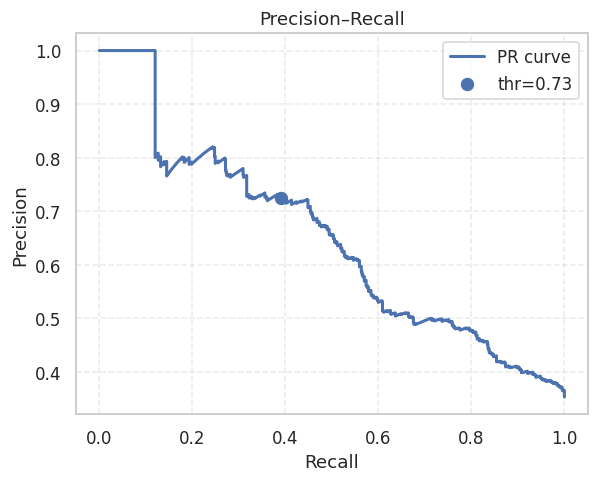

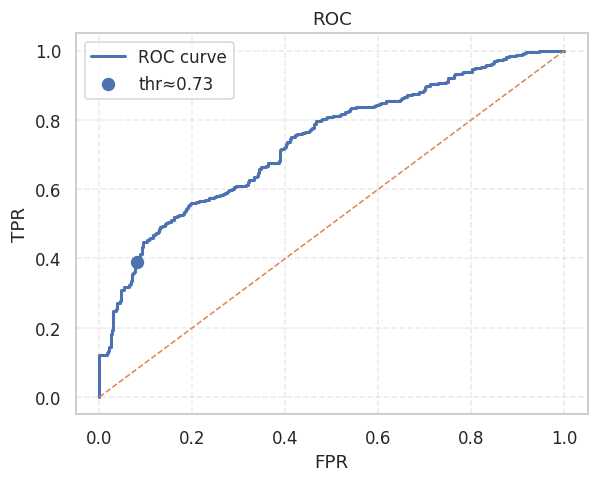

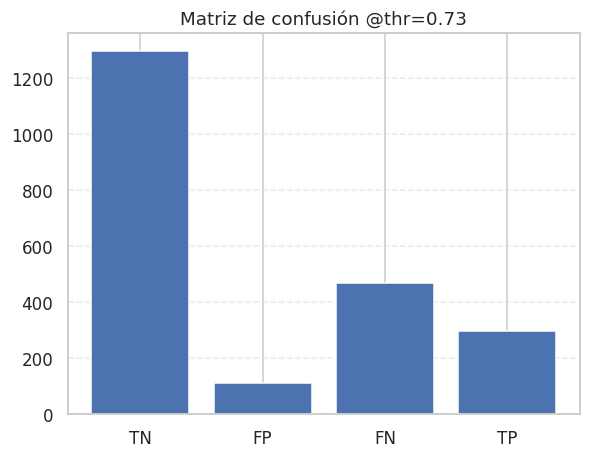

In [21]:
# === XGBoost solo, sin estandarizar: grid + métricas @thr=0.73 + gráficos ===
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
    confusion_matrix
)

# ------------------ Parámetros generales ------------------
PATH = "/home/srodriguezc/Simulador_de_compra_venta_de_acciones/Data/Merged/Dataset_final_prep_v2.csv"
TARGET = "activity_act"        # binaria 0/1
N_SPLITS = 5                   # CV temporal
SEED = 42
THRESHOLD = 0.73               # umbral operativo solicitado
SCORING_CV = "average_precision"  # PR-AUC en CV

# ------------------ Utilidades ------------------
def metrics_at(y_true, y_prob, thr, label=""):
    y_hat = (y_prob >= thr).astype(int)
    prec = precision_score(y_true, y_hat, zero_division=0)
    rec  = recall_score(y_true, y_hat, zero_division=0)
    f1   = f1_score(y_true, y_hat, zero_division=0)
    roc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    print(f"\n— {label} @thr={thr:.3f} —")
    print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f} | PR-AUC: {ap:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    return dict(precision=prec, recall=rec, f1=f1, roc_auc=roc, pr_auc=ap, tn=tn, fp=fp, fn=fn, tp=tp)

def plot_pr_roc(y_true, y_prob, thr):
    # --- PR curve ---
    p, r, t = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6.0, 4.5))
    plt.plot(r, p, lw=2, label="PR curve")
    # punto al umbral
    y_hat_thr = (y_prob >= thr).astype(int)
    p_thr = precision_score(y_true, y_hat_thr, zero_division=0)
    r_thr = recall_score(y_true, y_hat_thr, zero_division=0)
    plt.scatter([r_thr], [p_thr], s=60, label=f"thr={thr:.2f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
    plt.legend(); plt.grid(True, ls="--", alpha=0.4)
    plt.show()

    # --- ROC curve ---
    fpr, tpr, t_roc = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6.0, 4.5))
    plt.plot(fpr, tpr, lw=2, label="ROC curve")
    # punto al umbral (aprox. más cercano)
    idx = np.argmin(np.abs(t_roc - thr))
    plt.scatter([fpr[idx]], [tpr[idx]], s=60, label=f"thr≈{t_roc[idx]:.2f}")
    plt.plot([0,1],[0,1], lw=1, ls="--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")
    plt.legend(); plt.grid(True, ls="--", alpha=0.4)
    plt.show()

    # --- Confusion matrix (barras) ---
    tn, fp, fn, tp = confusion_matrix(y_true, (y_prob >= thr).astype(int)).ravel()
    plt.figure(figsize=(6.0, 4.5))
    plt.bar(["TN","FP","FN","TP"], [tn, fp, fn, tp])
    plt.title(f"Matriz de confusión @thr={thr:.2f}")
    plt.grid(True, ls="--", axis="y", alpha=0.4)
    plt.show()

# ------------------ Carga y preprocesamiento (igual a tu pipeline) ------------------
df = pd.read_csv(PATH)
print(f"✅ Dataset crudo: {df.shape[0]:,} filas × {df.shape[1]} columnas")

# Limpieza útil
if "insider_rating" in df.columns:
    df["insider_rating"] = pd.to_numeric(
        df["insider_rating"].astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce"
    )

# Encoding cíclico
if "quarter" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter'.")
q = pd.to_numeric(df["quarter"], errors="coerce")
df["quarter_sin"] = np.sin(2*np.pi*q/4)
df["quarter_cos"] = np.cos(2*np.pi*q/4)

if "quarter - year" not in df.columns:
    raise ValueError("No se encontró la columna 'quarter - year'.")
qy_raw = df["quarter - year"].astype(str)
qy_dt = pd.to_datetime(qy_raw, errors="coerce")
mask_nan = qy_dt.isna()
if mask_nan.any():
    def q_to_date(txt):
        m = re.match(r"Q([1-4])\s+(\d{4})", str(txt))
        if not m:
            return pd.NaT
        qn = int(m.group(1)); yy = int(m.group(2))
        month_end = {1:3, 2:6, 3:9, 4:12}[qn]
        return pd.Timestamp(year=yy, month=month_end, day=1) + pd.offsets.MonthEnd(0)
    qy_dt.loc[mask_nan] = qy_raw[mask_nan].map(q_to_date)

qy_quarter = qy_dt.dt.quarter.astype("float64")
df["quarter_year_sin"] = np.sin(2*np.pi*qy_quarter/4)
df["quarter_year_cos"] = np.cos(2*np.pi*qy_quarter/4)

# Eliminar duplicados cíclicos si aplica
try:
    same_sin = np.allclose(df["quarter_sin"].to_numpy(), df["quarter_year_sin"].to_numpy(), equal_nan=True)
    same_cos = np.allclose(df["quarter_cos"].to_numpy(), df["quarter_year_cos"].to_numpy(), equal_nan=True)
    if same_sin and same_cos:
        df.drop(columns=["quarter_year_sin", "quarter_year_cos"], inplace=True)
        print("ℹ️ 'quarter_year_*' duplicaba a 'quarter_*' y fue eliminado.")
except KeyError:
    pass

# Eliminar columnas de fecha crudas
for col in ["quarter - year", "Date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Target + OHE
if TARGET not in df.columns:
    raise ValueError(f"No se encontró la columna target '{TARGET}'.")
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

# Asegurar binaria
y_series = df[TARGET].astype(int)
if len(np.unique(y_series)) != 2:
    raise ValueError("La variable target debe ser binaria (0/1).")

cat_cols = [c for c in ["Ticker", "nombre_holding"] if c in df.columns]
df_ohe = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=np.uint8)

y = y_series.reindex(df_ohe.index).astype(int)
X = df_ohe.drop(columns=[TARGET])

# Booleans -> numérico
for c in X.select_dtypes(include=["boolean"]).columns.tolist():
    X[c] = X[c].astype(np.uint8)

# Imputación
X = X.fillna(X.median(numeric_only=True))

print(f"✅ Dataset post-encoding: {X.shape[0]:,} filas × {X.shape[1]} columnas (sin estandarizar)")

# ------------------ Split temporal 80/20 ------------------
n = len(X)
split_idx = int(n * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"🗂️ Train: {X_train.shape}, Test: {X_test.shape}")

# ------------------ XGBoost: grid y entrenamiento ------------------
from xgboost import XGBClassifier

# Peso relativo recomendado ~ (#neg/#pos) en TRAIN
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
ratio = neg / max(1, pos)
print(f"⚖️ scale_pos_weight base ≈ {ratio:.3f} (neg/pos en train)")

xgb = XGBClassifier(
    random_state=SEED,
    eval_metric="aucpr",
    tree_method="hist",
    n_estimators=600  # base; podemos moverlo en el grid si prefieres
)

param_grid = {
    "scale_pos_weight": [0.5*ratio, ratio, 2*ratio],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 1],
    "reg_lambda": [1, 5, 10],
    "reg_alpha": [0, 0.1, 1.0],
}

tss = TimeSeriesSplit(n_splits=N_SPLITS)
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=SCORING_CV,     # PR-AUC
    cv=tss,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)
grid_xgb.fit(X_train, y_train)

print("\n" + "="*70)
print("🔎 XGBoost — mejores hiperparámetros (CV temporal, scoring=PR-AUC)")
print(grid_xgb.best_params_)
print(f"PR-AUC (CV mean) del mejor: {grid_xgb.best_score_:.4f}")

# ------------------ Evaluación en holdout ------------------
proba_xgb = grid_xgb.predict_proba(X_test)[:, 1]

# Métricas @0.5 y @0.73
m05 = metrics_at(y_test.values, proba_xgb, 0.5, label="XGB (umbral 0.50)")
m73 = metrics_at(y_test.values, proba_xgb, THRESHOLD, label=f"XGB (umbral {THRESHOLD:.2f})")

# ------------------ Gráficos ------------------
plot_pr_roc(y_test.values, proba_xgb, THRESHOLD)


In [23]:
best_xgb = grid_xgb.best_estimator_
importances = best_xgb.get_booster().get_score(importance_type="gain")
imp = pd.Series(importances).sort_values(ascending=False).head(25)
print(imp)


Ticker_GSHD               38.562283
Ticker_META               21.661821
nombre_holding_BAUPOST    20.369772
nombre_holding_tp         18.457478
nombre_holding_HC         17.751621
Ticker_KR                 15.862761
nombre_holding_psc        15.236043
year                      14.045083
Ticker_ABNB               13.418381
netIncome                 13.115792
Ticker_NVDA               12.668103
activity_porc             12.642592
nombre_holding_AM         12.405779
quarter                   11.661202
nombre_holding_FS         11.203578
Ticker_CASY               10.867870
Ticker_MA                 10.732193
Ticker_GOOGL              10.436768
Ticker_EXPO               10.257509
ebitda                     9.716130
Ticker_COYA                9.112598
Ticker_ORLY                9.036823
quarter_cos                8.981712
quarter_sin                8.825945
Ticker_CVX                 8.825296
dtype: float64
